In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import seaborn as sns

In [5]:
df = pd.read_csv("News.csv")

In [6]:
df.head()

,Unnamed: 0,title,text,subject,date,class
0,0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [12]:
df = pd.read_csv("News.csv")

In [13]:
print(df.head())
print(df.info())

   Unnamed: 0                                              title  \
0           0   Donald Trump Sends Out Embarrassing New Year’...   
1           1   Drunk Bragging Trump Staffer Started Russian ...   
2           2   Sheriff David Clarke Becomes An Internet Joke...   
3           3   Trump Is So Obsessed He Even Has Obama’s Name...   
4           4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  class  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  
<class 'pandas.core.frame.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
'''TF-IDF Vectorization'''

X = df['text']
y = df['class']

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X = vectorizer.fit_transform(X)
print(X.shape)
print(y.shape)

(44919, 5000)
(44919,)


In [20]:
'''Split Dataset'''

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(35935, 5000)
(8984, 5000)


In [21]:
'''Logistic Regression'''

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy: 0.9861976847729297


In [22]:
'''Decision Tree'''

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9955476402493322


In [23]:
'''Classification Reports'''

print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4737
           1       0.98      0.99      0.99      4247

    accuracy                           0.99      8984
   macro avg       0.99      0.99      0.99      8984
weighted avg       0.99      0.99      0.99      8984

Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4737
           1       1.00      1.00      1.00      4247

    accuracy                           1.00      8984
   macro avg       1.00      1.00      1.00      8984
weighted avg       1.00      1.00      1.00      8984



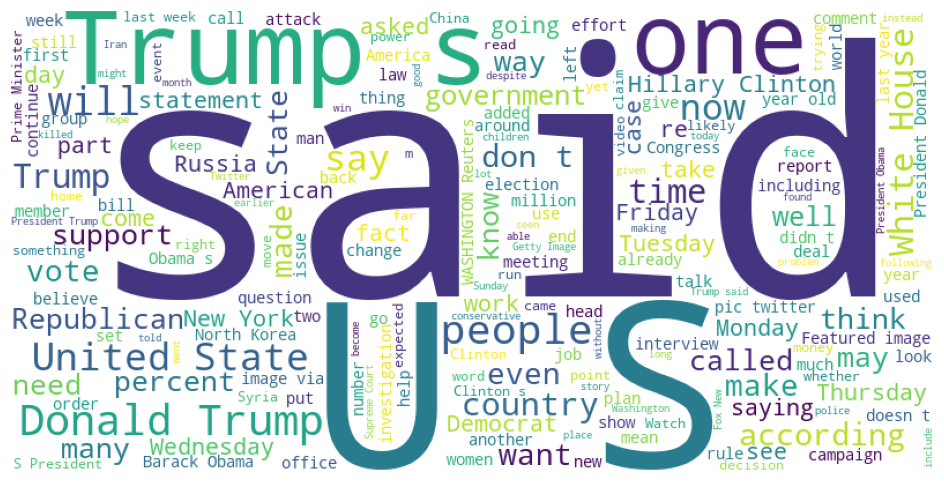

In [24]:
'''WordCloud'''

text = " ".join(df['text'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()